In [5]:
import numpy as np
import matplotlib.pyplot as plt
from specs import *
from meer21cm import MockSimulation
from meer21cm.telescope import dish_beam_sigma
from scipy.optimize import curve_fit
from meer21cm.power import bin_3d_to_cy, bin_3d_to_1d
from matplotlib.colors import LogNorm
import glob

In [2]:
def get_k_modes():
    mock = MockSimulation(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
    )
    mock.downres_factor_transverse = 3
    mock.downres_factor_radial = 6
    mock.get_enclosing_box()
    kperp_1 = mock.k_perp.copy()
    kpara_1 = mock.k_para.copy()
    kmode_1 = mock.k_mode.copy()
    kvec_1 = mock.k_vec.copy()
    return kperp_1, kpara_1, kmode_1, kvec_1
def bin_power_cy(
    power_3d,
    k_perp,
    k_para,
    kperpbins,
    kparabins,
    kweights=None,
):
    pcy_arr = bin_3d_to_cy(
        power_3d, k_perp, kperpbins, vectorize=True,
        weights=kweights,
    )
    pcy_arr = bin_3d_to_cy(
        np.nan_to_num(pcy_arr), np.abs(k_para), kparabins, vectorize=True,
        weights=(1-np.isnan(pcy_arr))[0].astype('float'),
    )
    return pcy_arr

def bin_power_1d(
    power_3d,
    k_mode,
    k1dbins,
    kweights,
    num_split=None,
):
    if num_split is None:
        p1d, keff, nmodes = bin_3d_to_1d(
            power_3d, k_mode, k1dbins, vectorize=True,weights=kweights,
        )
    else:
        p1d = []
        power_3d_arr = np.array_split(power_3d,num_split)
        for i in range(num_split):
            pdata1darr_i, keff, nmodes = bin_3d_to_1d(
                power_3d_arr[i], k_mode, k1dbins, vectorize=True,weights=kweights,
            )
            p1d.append(pdata1darr_i)
        p1d = np.concatenate(p1d)
    return p1d, keff, nmodes

In [3]:
kperp, kpara, kmode, kvec = get_k_modes()

In [6]:
file_arr = glob.glob('/users/ztchen/scratch3/validation/02/*.npz')

In [10]:
phi3d_arr = []
phimod3d_arr = []
pg3d_arr = []
pgmod3d_arr = []
pcross3d_arr = []
pcrossmod3d_arr = []
phiclean3d_arr = []
pcrossclean3d_arr = []
power_tf_before = []
power_tf_after = []
for file in file_arr:
    data = np.load(file)
    phi3d_arr.append(data['phi3d_arr'])
    phimod3d_arr.append(data['phimod3d_arr'])
    pg3d_arr.append(data['pg3d_arr'])
    pgmod3d_arr.append(data['pgmod3d_arr'])
    pcross3d_arr.append(data['pcross3d_arr'])
    pcrossmod3d_arr.append(data['pcrossmod3d_arr'])
    phiclean3d_arr.append(data['phiclean3d_arr'])
    pcrossclean3d_arr.append(data['pcrossclean3d_arr'])
    power_tf_before.append(data['power_tf_before'])
    power_tf_after.append(data['power_tf_after'])

In [11]:
phi3d_arr = np.array(phi3d_arr)
phimod3d_arr = np.array(phimod3d_arr)[0]
pg3d_arr = np.array(pg3d_arr)
pgmod3d_arr = np.array(pgmod3d_arr)[0]
pcross3d_arr = np.array(pcross3d_arr)
pcrossmod3d_arr = np.array(pcrossmod3d_arr)[0]
phiclean3d_arr = np.array(phiclean3d_arr)
pcrossclean3d_arr = np.array(pcrossclean3d_arr)
power_tf_before = np.array(power_tf_before)
power_tf_after = np.array(power_tf_after)

In [12]:
k_xy_sel = (
    (np.abs(kvec[0])<0.016)[:,None,None] 
    * (np.abs(kvec[1])<0.016)[None,:,None]
    * (np.abs(kvec[2])<10)[None,None,:]
)
k_xy_sel[0] = 0.0
k_xy_sel[:,0] = 0.0
k_xy_sel[:,:,0] = 0.0
k_cy_sel = np.ones_like(k_xy_sel)
k_cy_sel[0] = 0.0
k_cy_sel[:,0] = 0.0
k_cy_sel[:,:,0] = 0.0

In [17]:
phicy_arr = bin_power_cy(
    phi3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
phimodcy_arr = bin_power_cy(
    phimod3d_arr[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]


pgcy_arr = bin_power_cy(
    pg3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pgmodelcy_arr = bin_power_cy(
    pgmod3d_arr[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]



pxcy_arr = bin_power_cy(
    pcross3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)
pxmodelcy_arr = bin_power_cy(
    pcrossmod3d_arr[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)[0]

phicleancy_arr = bin_power_cy(
    phiclean3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)

pxcleancy_arr = bin_power_cy(
    pcrossclean3d_arr.mean(0)[None],
    kperp,
    kpara,
    kperpbins,
    kparabins,
    kweights=k_cy_sel,
)

/users/ztchen/meer21cm/src/meer21cm/power.py:2045: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


Text(0.5, 0.98, 'HI Auto, mock + model + ratio')

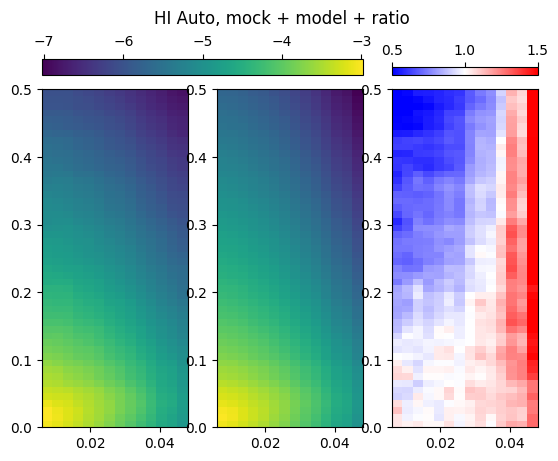

In [18]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperpbins,
    kparabins,
    phicy_arr,
    phimodcy_arr,
    0.5,
    1.5,
)
fig.suptitle('HI Auto, mock + model + ratio')

Text(0.5, 0.98, 'HI Auto , mock + cleaned + ratio, no beam')

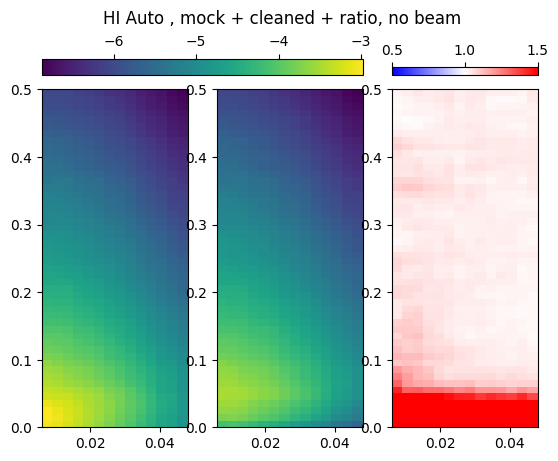

In [20]:
plt.rcParams.update({'font.size':10})
fig = plot_cy_power(
    kperpbins,
    kparabins,
    phicy_arr,
    phicleancy_arr[0],
    0.5,
    1.5,
)
fig.suptitle('HI Auto , mock + cleaned + ratio, no beam')

/users/ztchen/meer21cm/papers/validation/specs.py:51: RuntimeWarning: invalid value encountered in log10
  np.log10(pdatacy.mean(axis=0).T),
/users/ztchen/meer21cm/papers/validation/specs.py:61: RuntimeWarning: invalid value encountered in log10
  np.log10(pdatacy.mean(axis=0).T),


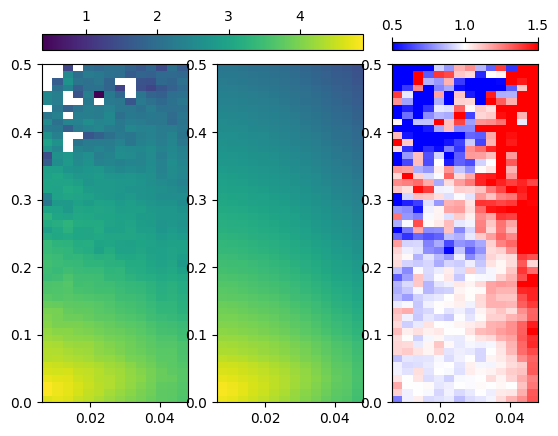

In [15]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pgcy_arr,
    pgmodelcy_arr,
    0.5,
    1.5,
)

Text(0.5, 0.98, 'Cross, mock + model + ratio')

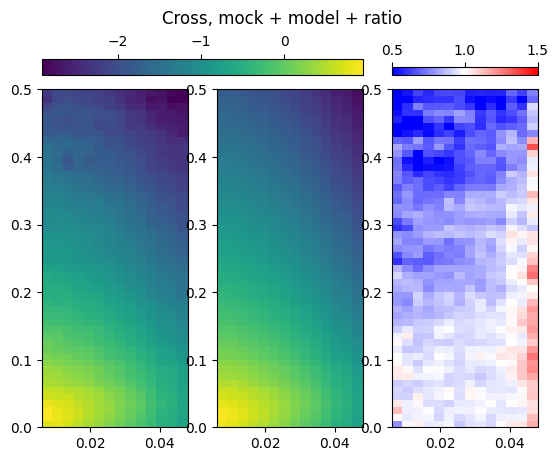

In [21]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcy_arr,
    pxmodelcy_arr,
    0.5,
    1.5,
)
fig.suptitle('Cross, mock + model + ratio')

Text(0.5, 0.98, 'Cross, mock + cleaned + ratio')

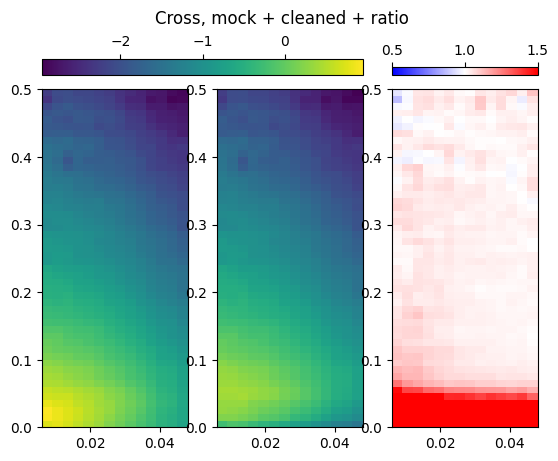

In [25]:
fig = plot_cy_power(
    kperpbins,
    kparabins,
    pxcy_arr,
    pxcleancy_arr[0],
    0.5,
    1.5,
)
fig.suptitle('Cross, mock + cleaned + ratio')

In [30]:
phi1darr, keff, nmodes = bin_power_1d(
    phi3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pmod1darr, keff, nmodes = bin_power_1d(
    phimod3d_arr[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pmod1darr = pmod1darr[0]

pg1darr, keff, nmodes = bin_power_1d(
    pg3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pgmod1darr, keff, nmodes = bin_power_1d(
    pgmod3d_arr[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pgmod1darr = pgmod1darr[0]

px1darr, keff, nmodes = bin_power_1d(
    pcross3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
    num_split=20,
)
pxmod1darr, keff, nmodes = bin_power_1d(
    pcrossmod3d_arr[None],
    kmode,
    k1dbins,
    k_xy_sel,
)
pxmod1darr = pxmod1darr[0]

ptfbefore1darr,_,_ = bin_power_1d(
    power_tf_before,
    kmode,
    k1dbins,
    k_xy_sel,
)
ptfafter1darr,_,_ = bin_power_1d(
    power_tf_after,
    kmode,
    k1dbins,
    k_xy_sel,
)
phiclean1darr,_,_ = bin_power_1d(
    phiclean3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
)
pxclean1darr,_,_ = bin_power_1d(
    pcrossclean3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
)

In [53]:
ptest1darr,_,_ = bin_power_1d(
    power_tf_before.mean(0)[None]/power_tf_after.mean(0)[None] * phiclean3d_arr,
    kmode,
    k1dbins,
    k_xy_sel,
)

In [32]:
tf_1d = ptfbefore1darr.mean(0)/ptfafter1darr.mean(0)

In [47]:
tf_1d = (ptfbefore1darr/ptfafter1darr)

/users/ztchen/meer21cm/papers/validation/specs.py:130: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


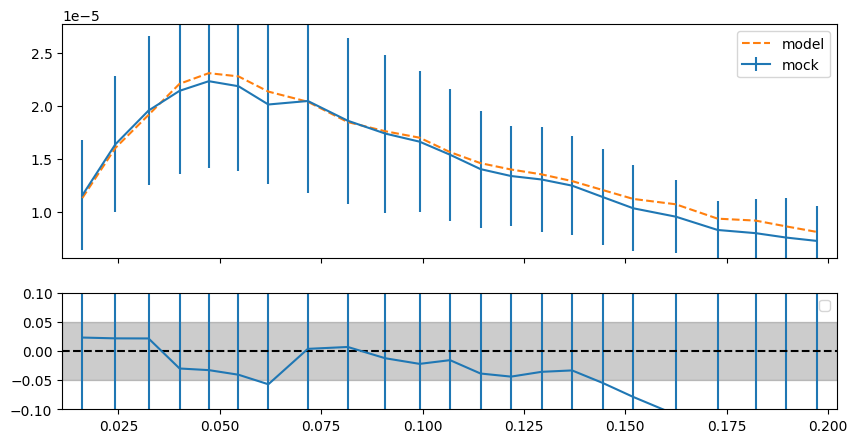

In [27]:
plot_1d_power(
        keff,
        phi1darr,
        pmod1darr,
        -0.1,
        0.1,
    );

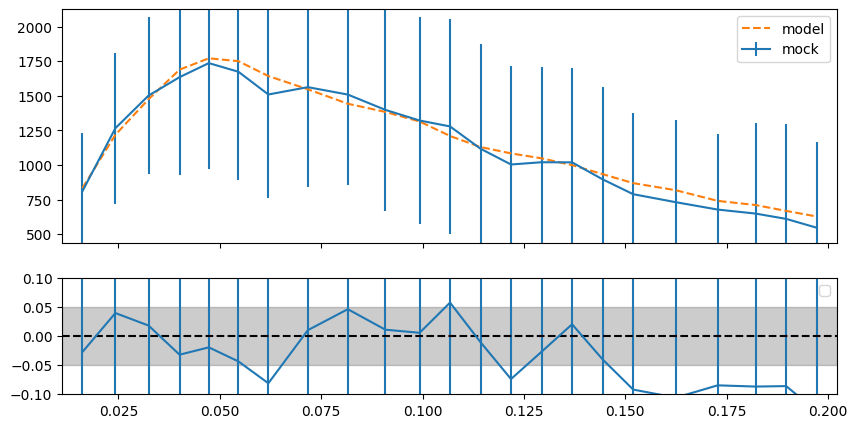

In [28]:
plot_1d_power(
        keff,
        pg1darr,
        pgmod1darr,
        -0.1,
        0.1,
    );

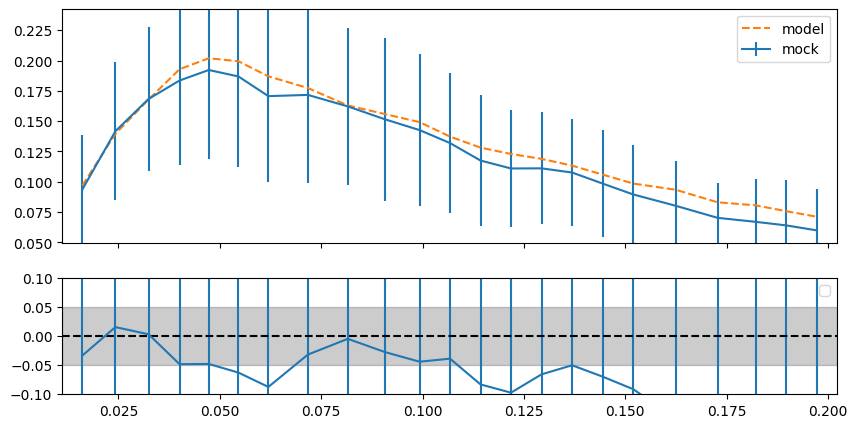

In [29]:
plot_1d_power(
        keff,
        px1darr,
        pxmod1darr,
        -0.1,
        0.1,
    );

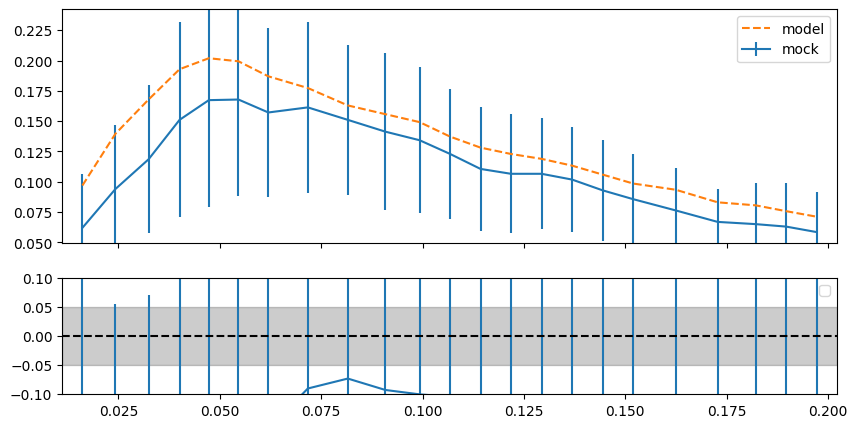

In [37]:
plot_1d_power(
        keff,
        pxclean1darr*tf_1d[None],
        pxmod1darr,
        -0.1,
        0.1,
    );

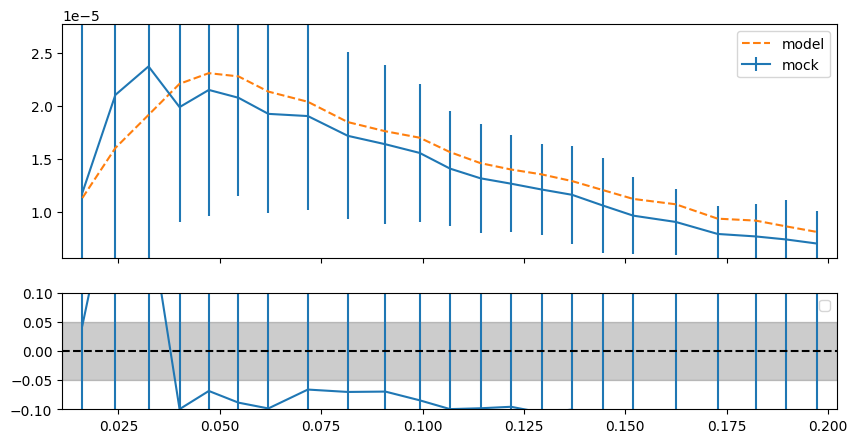

In [49]:
plot_1d_power(
        keff,
        phiclean1darr*tf_1d,
        pmod1darr,
        -0.1,
        0.1,
    );

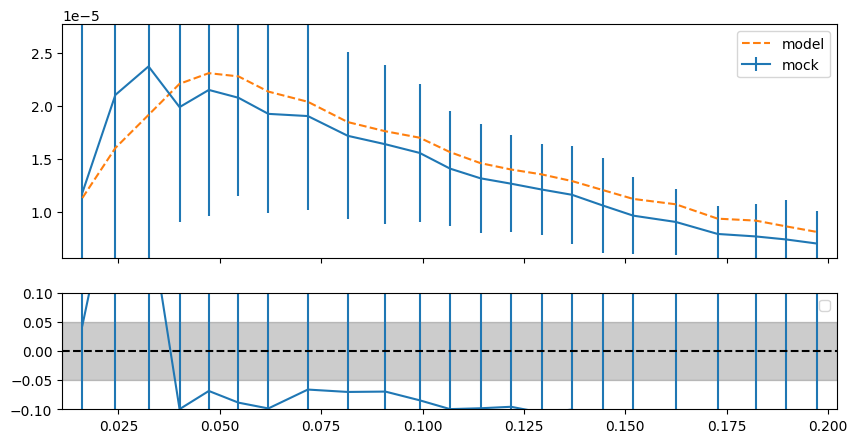

In [48]:
plot_1d_power(
        keff,
        phiclean1darr * tf_1d,
        pmod1darr,
        -0.1,
        0.1,
    );

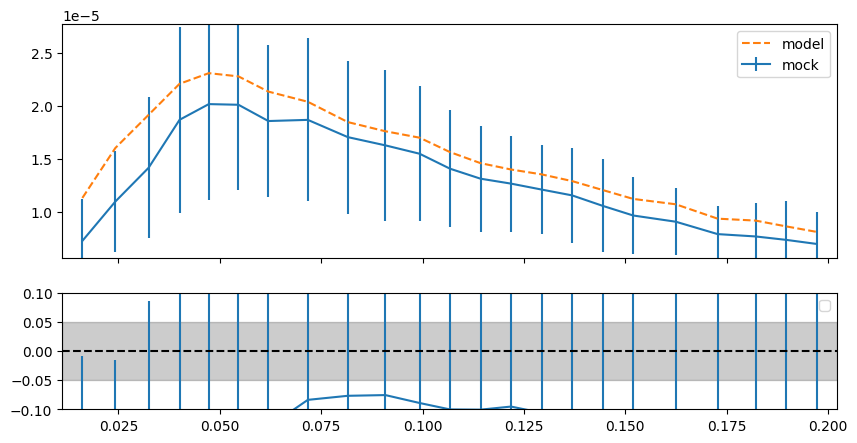

In [54]:
plot_1d_power(
        keff,
        ptest1darr,
        pmod1darr,
        -0.1,
        0.1,
    );